# KernelGap Synthetic Dataset v3

OPTION 4, with KTA as objective function.
Experiments conducted:
- Optuna w/ KTA, 100 trials
- Mealpy w/ KTA, 30 generations, 10 population size
- Optuna w/ KTA, 200 trials
- Mealpy w/ KTA, 60 generations, 10 population size

In [53]:
# ── 0. Imports ─────────────────────────────────────────────────────────────────
from config.config import *
from config.experiments import ExperimentConfig

import src.data.saving as saving
import src.utils.visuals as visuals

from src.data.preprocessing import preprocess_synthetic
from src.data.synthetic import KernelGap_synthetic_dataset
from src.data.saving import candidate_exists, svm_exists, load_parameter_train, load_svm_results
from src.data.subsets import subset_random, subset_nystrom_global, subset_nystrom_stratified
from src.kernel.quantum_kernel import quantum_kernel_matrix_cross
from src.optimization.pipeline import get_candidate, get_svm_results
from src.optimization.training_candidate import train_candidate_optuna_angles
from src.optimization.classical_base import classical_baseline
from src.utils.visuals import *

from src.kernel.metrics import geometric_difference

In [54]:
# ── 1. Data ────────────────────────────────────────────────────────────────
X, y = KernelGap_synthetic_dataset(seed=45)
X_train, X_test, y_train, y_test = preprocess_synthetic(X, y, N_QUBITS)

RESULTS_DIR = 'Results/KernelGap Synthetic v2'
saving.RESULTS_DIR = RESULTS_DIR
visuals.RESULTS_DIR = RESULTS_DIR

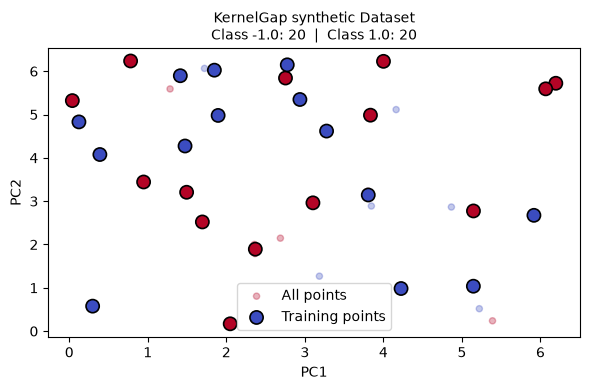

In [55]:
# ── 2. Dataset structure ─────────────────────────────────────────────────────────
graph_dataset('KernelGap synthetic', X, y, X_train, y_train, 'yes')

In [56]:
# ── 3. Experiments ─────────────────────────────────────────────────────────────
# This is the main section to edit. Each ExperimentConfig defines one run.
# Comment out any you don't want to include.
#
# name             → used as the Results subfolder name; must be unique
# optimizer        → 'optuna' or 'mealpy'
# variant          → 'geometric', 'haar', 'angles'
# subset_method    → 'random', 'nystrom_global', or 'nystrom_stratified'
# subset_kwargs    → passed to the chosen subset function
# optimizer_kwargs → passed to the chosen optimizer
# load_from        → (optional) load candidate from a different experiment name

EXPERIMENTS: list[ExperimentConfig] = [
    ExperimentConfig(
        name='optuna kta 2',
        optimizer='optuna',
        variant='kta',
        subset_method='none',
        optimizer_kwargs={'n_trials': N_TRIALS},
    ),
    ExperimentConfig(
        name='mealpy kta 2',
        optimizer='mealpy',
        variant='kta',
        subset_method='none',
        optimizer_kwargs = {'n_epoch': N_EPOCH, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM},
    ),
    ExperimentConfig(
        name='optuna kta 3',
        optimizer='optuna',
        variant='kta',
        subset_method='none',
        optimizer_kwargs={'n_trials': N_TRIALS},
    ),
    ExperimentConfig(
        name='mealpy kta 3',
        optimizer='mealpy',
        variant='kta',
        subset_method='none',
        optimizer_kwargs = {'n_epoch': N_EPOCH, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM},
    ),
    ExperimentConfig(
        name='optuna kta 4',
        optimizer='optuna',
        variant='kta',
        subset_method='none',
        optimizer_kwargs={'n_trials': 200},
    ),
    ExperimentConfig(
        name='mealpy kta 4',
        optimizer='mealpy',
        variant='kta',
        subset_method='none',
        optimizer_kwargs = {'n_epoch': 60, 'n_pop_size': N_POPSIZE, 'n_pm': N_PM},
    ),
]

In [57]:
# ── 4. Run ─────────────────────────────────────────────────────────────────────
# Cached results are reused automatically; delete Results/{name}/svm.pkl or
# Results/{name}/candidate.pkl to force a fresh run for that experiment.
 
summary = {}   # name → {accuracy, cv_acc, g_best, best_C}

# ── Classical baseline ──────────────────────────────────────────────────────
BASELINE = 'Classical_baseline 2'
if svm_exists(BASELINE):
    print(f"\nLoaded results of SVM for '{BASELINE}'")
    baseline_res = load_svm_results(BASELINE)
else:
    baseline_res = classical_baseline(X_train, y_train, X_test, y_test, name=BASELINE)
 
summary[BASELINE] = {
    'accuracy': baseline_res['accuracy'],
    'cv_acc':   float(baseline_res['best_cv_accuracy']),
    'best_C':   baseline_res['best_C'],
    'g_best':   float('nan'),
}

# ── Quantum experiments ─────────────────────────────────────────────────────
for config in EXPERIMENTS:
    print(f"\n{'─' * 60}")
    print(f" {config.name}  [{config.optimizer} + {config.subset_method}]")
    print(f"{'─' * 60}")

    # Step 1: Candidate (train or load from cache)
    candidate, K_train, K_classical, X_sub, y_sub = get_candidate(config, X_train, y_train)
    g_best = load_parameter_train(config.load_from or config.name).get('g_best', float('nan'))
    
    # Step 2: SVM (run or load from cache)
    K_test = None
    if not svm_exists(config.name):
        print("Computing cross-kernel (test × subset)…")
        K_test = quantum_kernel_matrix_cross(X_test, X_sub, candidate)
    
    results = get_svm_results(config, K_train, y_sub, K_test, y_test)
    
    summary[config.name] = {
        'accuracy': results['accuracy'],
        'cv_acc':   float(results['best_cv_accuracy']),
        'best_C':   results['best_C'],
        'g_best':   g_best,
    }

[I 2026-08-22 11:46:22,352] A new study created in memory with name: no-name-d39e3fae-c058-4ee1-8f87-f4e4492a5d6b



Loaded results of SVM for 'Classical_baseline 2'

────────────────────────────────────────────────────────────
 optuna kta 2  [optuna + none]
────────────────────────────────────────────────────────────
Loading cached candidate for 'optuna kta 2'
Loading cached SVM results for 'optuna kta 2'

────────────────────────────────────────────────────────────
 mealpy kta 2  [mealpy + none]
────────────────────────────────────────────────────────────
Loading cached candidate for 'mealpy kta 2'
Loading cached SVM results for 'mealpy kta 2'

────────────────────────────────────────────────────────────
 optuna kta 3  [optuna + none]
────────────────────────────────────────────────────────────
Loading cached candidate for 'optuna kta 3'
Loading cached SVM results for 'optuna kta 3'

────────────────────────────────────────────────────────────
 mealpy kta 3  [mealpy + none]
────────────────────────────────────────────────────────────
Loading cached candidate for 'mealpy kta 3'
Loading cached SVM r

[I 2026-08-22 11:46:25,165] Trial 0 finished with value: 0.05835020309131902 and parameters: {'gate_0': 'RY', 'angle_0': 2.7423836543493483, 'gate_1': 'I', 'angle_1': 1.0516514152273355, 'gate_2': 'H', 'angle_2': 3.761965566391265, 'gate_3': 'I', 'angle_3': 3.758974197607288, 'gate_4': 'RX', 'angle_4': 2.2823913437597967, 'gate_5': 'H', 'angle_5': 3.816979432580191, 'gate_6': 'RZ', 'angle_6': 2.6227067438878535, 'gate_7': 'H', 'angle_7': 5.885665465232997, 'gate_8': 'RZ', 'angle_8': 5.105762083511278, 'gate_9': 'RX', 'angle_9': 1.4831564216925377, 'gate_10': 'RX', 'angle_10': 3.6801724020334636, 'gate_11': 'CNOT', 'angle_11': 4.2602110014867, 'gate_12': 'RZ', 'angle_12': 1.3066250557299717, 'gate_13': 'RX', 'angle_13': 2.200033432429177, 'gate_14': 'H', 'angle_14': 3.615498695695252, 'gate_15': 'CNOT', 'angle_15': 2.366767155822463}. Best is trial 0 with value: 0.05835020309131902.
[I 2026-08-22 11:46:27,681] Trial 1 finished with value: 0.1038146470050967 and parameters: {'gate_0': 'R

Saved candidate  → Results/KernelGap Synthetic v2/optuna kta 4/candidate.pkl
Computing cross-kernel (test × subset)…


2026/08/22 11:54:38 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: BaseGA(epoch=60, pop_size=20, pc=0.95, pm=0.1)


Saved SVM        → Results/KernelGap Synthetic v2/optuna kta 4/svm.pkl

REPORT: optuna kta 4 | 100 trials
Best C            : 0.1
Best CV accuracy  : 0.6667
Test accuracy     : 0.8333
              precision    recall  f1-score   support

        -1.0       0.75      1.00      0.86         6
         1.0       1.00      0.67      0.80         6

    accuracy                           0.83        12
   macro avg       0.88      0.83      0.83        12
weighted avg       0.88      0.83      0.83        12


────────────────────────────────────────────────────────────
 mealpy kta 4  [mealpy + none]
────────────────────────────────────────────────────────────


2026/08/22 11:55:48 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: 0.22601290933378237, Global best: 0.22601290933378237, Runtime: 34.70804 seconds
2026/08/22 11:56:22 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: 0.20618376982804995, Global best: 0.22601290933378237, Runtime: 33.49343 seconds
2026/08/22 11:56:56 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: 0.18923305066982804, Global best: 0.22601290933378237, Runtime: 33.60519 seconds
2026/08/22 11:57:31 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: 0.18466107155173636, Global best: 0.22601290933378237, Runtime: 35.38535 seconds
2026/08/22 11:58:05 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: 0.22010001805033746, Global best: 0.22601290933378237, Runtime: 34.40807 seconds
2026/08/22 11:58:39 AM, INFO, mealpy.evolutionary_based.GA.BaseGA

Saved candidate  → Results/KernelGap Synthetic v2/mealpy kta 4/candidate.pkl
Computing cross-kernel (test × subset)…
Saved SVM        → Results/KernelGap Synthetic v2/mealpy kta 4/svm.pkl

REPORT: mealpy kta 4 | 30 epochs | 20 pop | 0.1 pm
Best C            : 0.1
Best CV accuracy  : 0.7000
Test accuracy     : 0.5833
              precision    recall  f1-score   support

        -1.0       0.57      0.67      0.62         6
         1.0       0.60      0.50      0.55         6

    accuracy                           0.58        12
   macro avg       0.59      0.58      0.58        12
weighted avg       0.59      0.58      0.58        12



In [64]:
data = load_parameter_train('optuna kta 4')
g = geometric_difference(data['K_classical'], data['K_quantum'])
print(f"Geometric difference optuna kta 4 = {g:.4f}")

data = load_parameter_train('mealpy kta 4')
g = geometric_difference(data['K_classical'], data['K_quantum'])
print(f"Geometric difference mealpy kta 4 = {g:.4f}")

Geometric difference optuna kta 4 = 8.5798
Geometric difference mealpy kta 4 = 7.7529


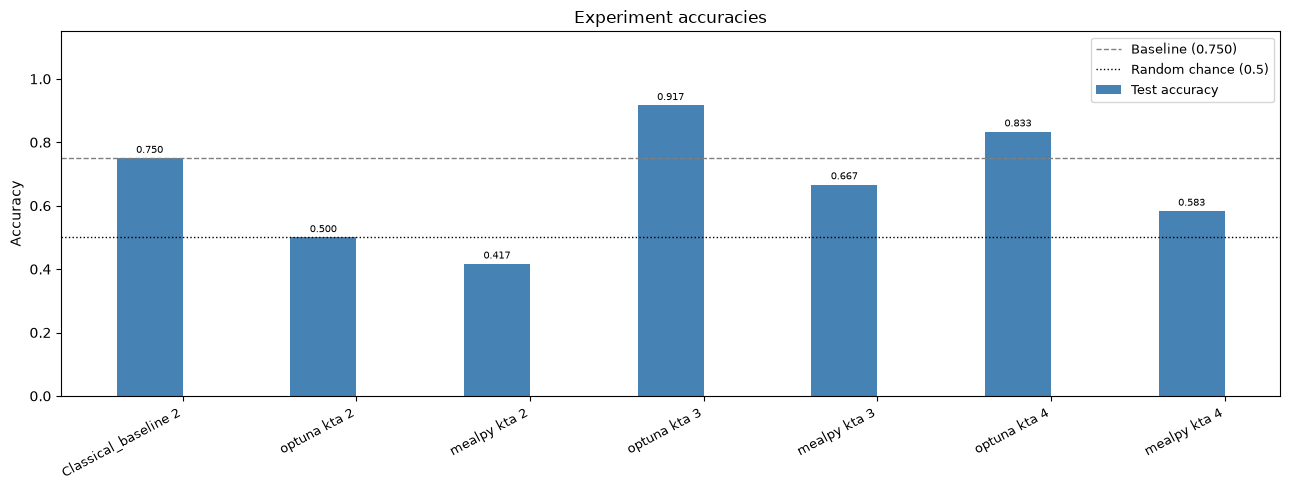

Saved → Results/KernelGap Synthetic v2/accuracy_comparison.png


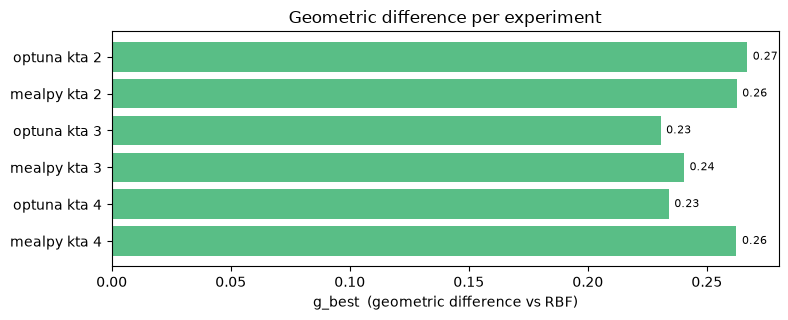

Saved → Results/KernelGap Synthetic v2/g_best_comparison.png


In [65]:
# ── 6. Visualizations ──────────────────────────────────────────────────────────
def plot_accuracy(summary: dict, columns) -> None:
    """
    Grouped bar chart: test accuracy vs CV accuracy for every experiment.
    Args:
        summary (dict): data to plot
        options (array): choose which columns to plot. available: ['test', 'CV']
    """
    names     = list(summary.keys())
    test_acc  = [s['accuracy'] for s in summary.values()]
    cv_acc    = [s['cv_acc']   for s in summary.values()]
    baseline  = summary[BASELINE]['accuracy']
 
    x, w = np.arange(len(names)), 0.38
    fig, ax = plt.subplots(figsize=(13, 5))
    if 'test' in columns:
        b1 = ax.bar(x - w/2, test_acc, w, label='Test accuracy', color='steelblue')
        ax.bar_label(b1, fmt='%.3f', fontsize=7.5, padding=2)
    if 'CV' in columns:
        b2 = ax.bar(x + w/2, cv_acc,   w, label='CV accuracy',   color='coral', alpha=0.85)
        ax.bar_label(b2, fmt='%.3f', fontsize=7.5, padding=2)
    ax.axhline(baseline, color='grey', linestyle='--', linewidth=1, label=f'Baseline ({baseline:.3f})')
    ax.axhline(0.5, color='black', linestyle=':', linewidth=1, label='Random chance (0.5)')
 
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=28, ha='right', fontsize=9)
    #ax.set_ylim(max(0, min(test_acc + cv_acc) - 0.08), 1.05)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Accuracy')
    ax.set_title('Experiment accuracies')
    ax.legend(fontsize=9)
 
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/accuracy_comparison.png', dpi=150)
    plt.show()
    print(f"Saved → {RESULTS_DIR}/accuracy_comparison.png")

plot_accuracy(summary, ['test'])
plot_g_best(summary)

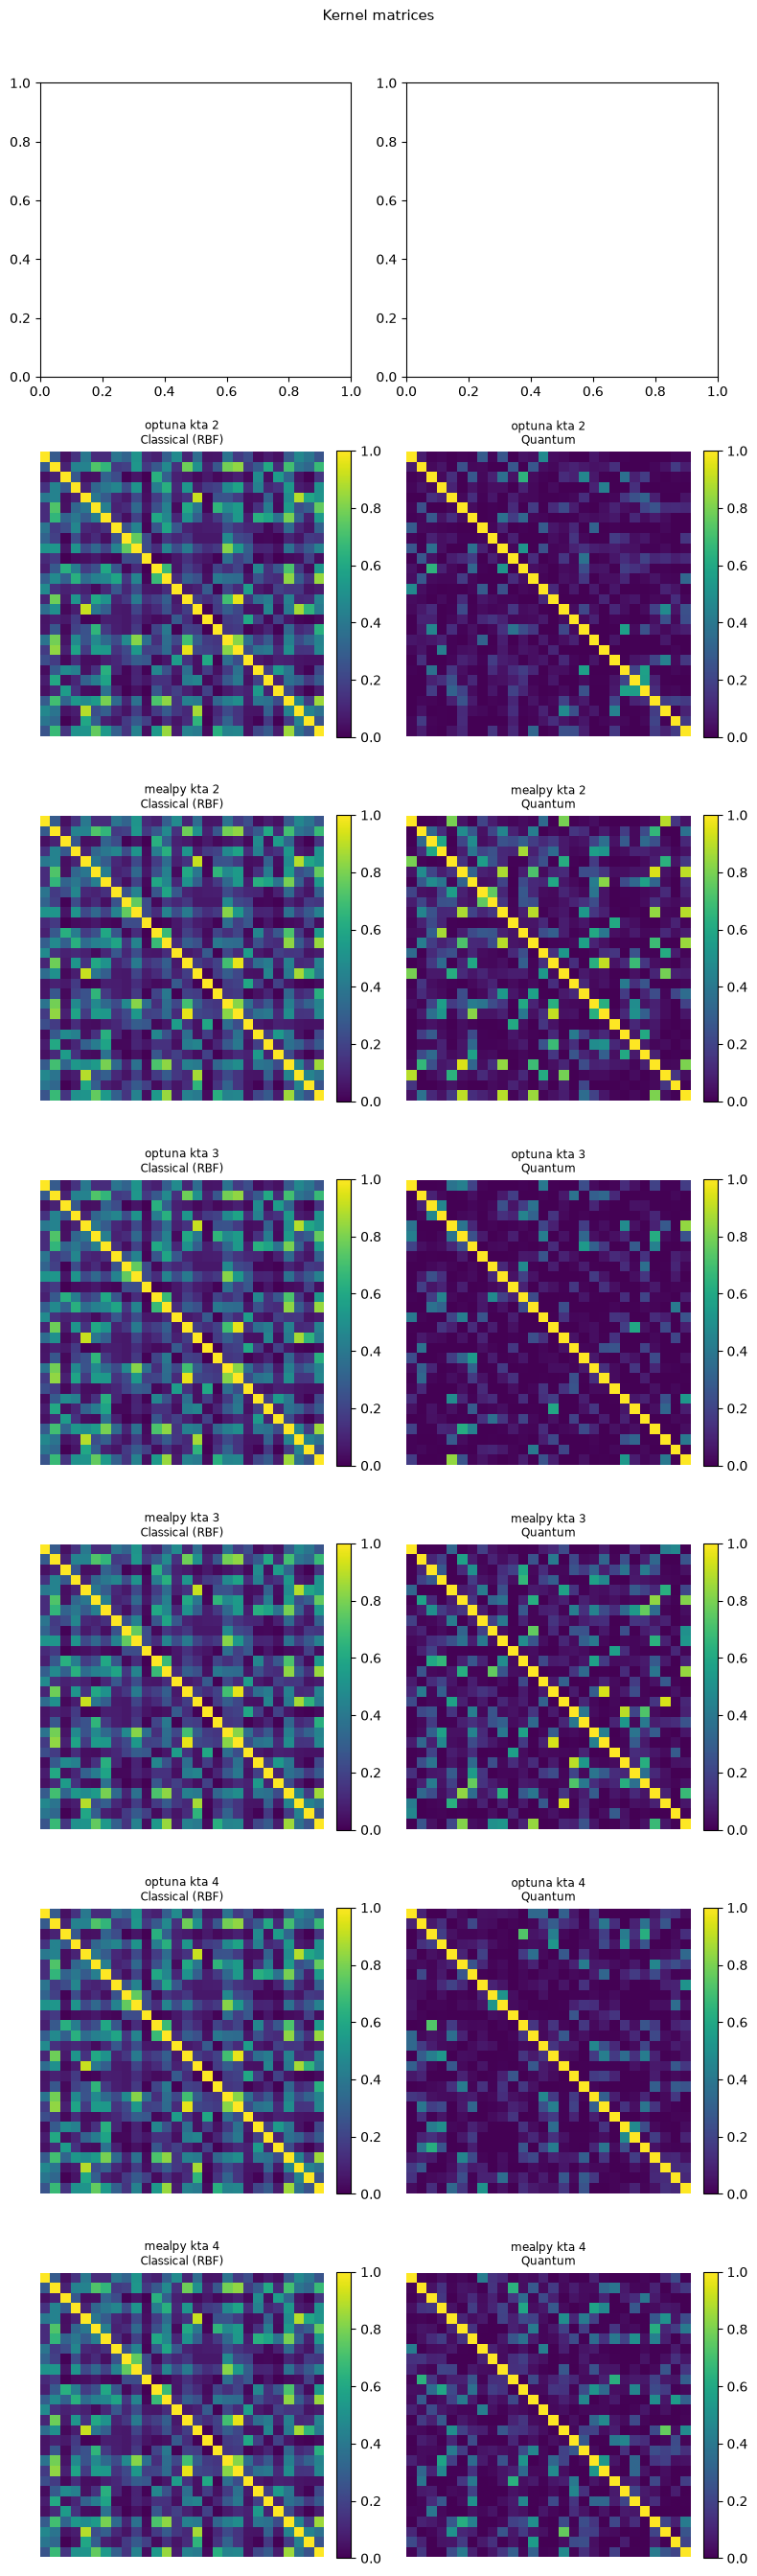

Saved → Results/KernelGap Synthetic v2/kernel_heatmaps.png


In [67]:
plot_kernel_heatmaps(summary)